In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score, adjusted_rand_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.preprocessing import PowerTransformer
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor, VotingRegressor, BaggingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from statsmodels.stats.outliers_influence import variance_inflation_factor
import joblib



In [40]:
df = pd.read_csv('Life Expectancy Data.csv')
df.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [41]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   str    
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   str    
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10   BMI                             2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio                          

In [42]:
df.shape

(2938, 22)

In [43]:
df = df.rename(columns=lambda x: x.strip().replace(' ', '_').replace('-', '_').title())
df.isnull().sum()

Country                              0
Year                                 0
Status                               0
Life_Expectancy                     10
Adult_Mortality                     10
Infant_Deaths                        0
Alcohol                            194
Percentage_Expenditure               0
Hepatitis_B                        553
Measles                              0
Bmi                                 34
Under_Five_Deaths                    0
Polio                               19
Total_Expenditure                  226
Diphtheria                          19
Hiv/Aids                             0
Gdp                                448
Population                         652
Thinness__1_19_Years                34
Thinness_5_9_Years                  34
Income_Composition_Of_Resources    167
Schooling                          163
dtype: int64

In [44]:
# Drop rows with missing target variable
df.dropna(subset=['Life_Expectancy'], inplace=True)

# Removing year & Country
df.drop(["Year", "Country"], axis=1, inplace=True)

In [45]:
df.isnull().sum()

Status                               0
Life_Expectancy                      0
Adult_Mortality                      0
Infant_Deaths                        0
Alcohol                            193
Percentage_Expenditure               0
Hepatitis_B                        553
Measles                              0
Bmi                                 32
Under_Five_Deaths                    0
Polio                               19
Total_Expenditure                  226
Diphtheria                          19
Hiv/Aids                             0
Gdp                                443
Population                         644
Thinness__1_19_Years                32
Thinness_5_9_Years                  32
Income_Composition_Of_Resources    160
Schooling                          160
dtype: int64

In [46]:
# Fill missing values with mean
df["Alcohol"] = df["Alcohol"].fillna(df["Alcohol"].mean(), inplace=True)
df["Hepatitis_B"] = df["Hepatitis_B"].fillna(df["Hepatitis_B"].mean(), inplace=True)
df["Bmi"] = df["Bmi"].fillna(df["Bmi"].mean(), inplace=True)
df["Polio"] = df["Polio"].fillna(df["Polio"].mean(), inplace=True)
df["Total_Expenditure"] = df["Total_Expenditure"].fillna(df["Total_Expenditure"].mean(), inplace=True)
df["Diphtheria"] = df["Diphtheria"].fillna(df["Diphtheria"].mean(), inplace=True)
df["Gdp"] = df["Gdp"].fillna(df["Gdp"].mean(), inplace=True)
df["Population"] = df["Population"].fillna(df["Population"].mean(), inplace=True)
df["Thinness__1_19_Years"] = df["Thinness__1_19_Years"].fillna(df["Thinness__1_19_Years"].mean(), inplace=True)
df["Thinness_5_9_Years"] = df["Thinness_5_9_Years"].fillna(df["Thinness_5_9_Years"].mean(), inplace=True)
df["Income_Composition_Of_Resources"] = df["Income_Composition_Of_Resources"].fillna(df["Income_Composition_Of_Resources"].mean(), inplace=True)
df["Schooling"] = df["Schooling"].fillna(df["Schooling"].mean(), inplace=True)

In [47]:
df.duplicated().sum()

np.int64(0)

In [48]:
df.describe(include=['int64', 'float64']).T

,count,mean,std,min,25%,50%,75%,max
Life_Expectancy,2928.0,6.922493e+01,9.523867e+00,36.30000,63.100000,7.210000e+01,7.570000e+01,8.900000e+01
Adult_Mortality,2928.0,1.647964e+02,1.242921e+02,1.00000,74.000000,1.440000e+02,2.280000e+02,7.230000e+02
Infant_Deaths,2928.0,3.040745e+01,1.181144e+02,0.00000,0.000000,3.000000e+00,2.200000e+01,1.800000e+03
Alcohol,2928.0,4.614856e+00,3.914923e+00,0.01000,1.107500,4.160000e+00,7.400000e+00,1.787000e+01
Percentage_Expenditure,2928.0,7.403212e+02,1.990931e+03,0.00000,4.853964,6.561145e+01,4.426143e+02,1.947991e+04
Hepatitis_B,2928.0,8.096084e+01,2.253136e+01,1.00000,80.960842,8.700000e+01,9.600000e+01,9.900000e+01
Measles,2928.0,2.427856e+03,1.148597e+04,0.00000,0.000000,1.700000e+01,3.622500e+02,2.121830e+05
Bmi,2928.0,3.823539e+01,1.985018e+01,1.00000,19.400000,4.300000e+01,5.610000e+01,7.760000e+01
Under_Five_Deaths,2928.0,4.217930e+01,1.607005e+02,0.00000,0.000000,4.000000e+00,2.800000e+01,2.500000e+03
Polio,2928.0,8.254830e+01,2.334055e+01,3.00000,78.000000,9.300000e+01,9.700000e+01,9.900000e+01


In [49]:
df.select_dtypes(include=np.number).skew()

Life_Expectancy                    -0.638605
Adult_Mortality                     1.174369
Infant_Deaths                       9.771044
Alcohol                             0.607622
Percentage_Expenditure              4.643790
Hepatitis_B                        -2.146879
Measles                             9.425290
Bmi                                -0.231828
Under_Five_Deaths                   9.479623
Polio                              -2.104791
Total_Expenditure                   0.600863
Diphtheria                         -2.079352
Hiv/Aids                            5.386623
Gdp                                 3.476242
Population                         18.010899
Thinness__1_19_Years                1.720041
Thinness_5_9_Years                  1.786369
Income_Composition_Of_Resources    -1.174653
Schooling                          -0.600505
dtype: float64

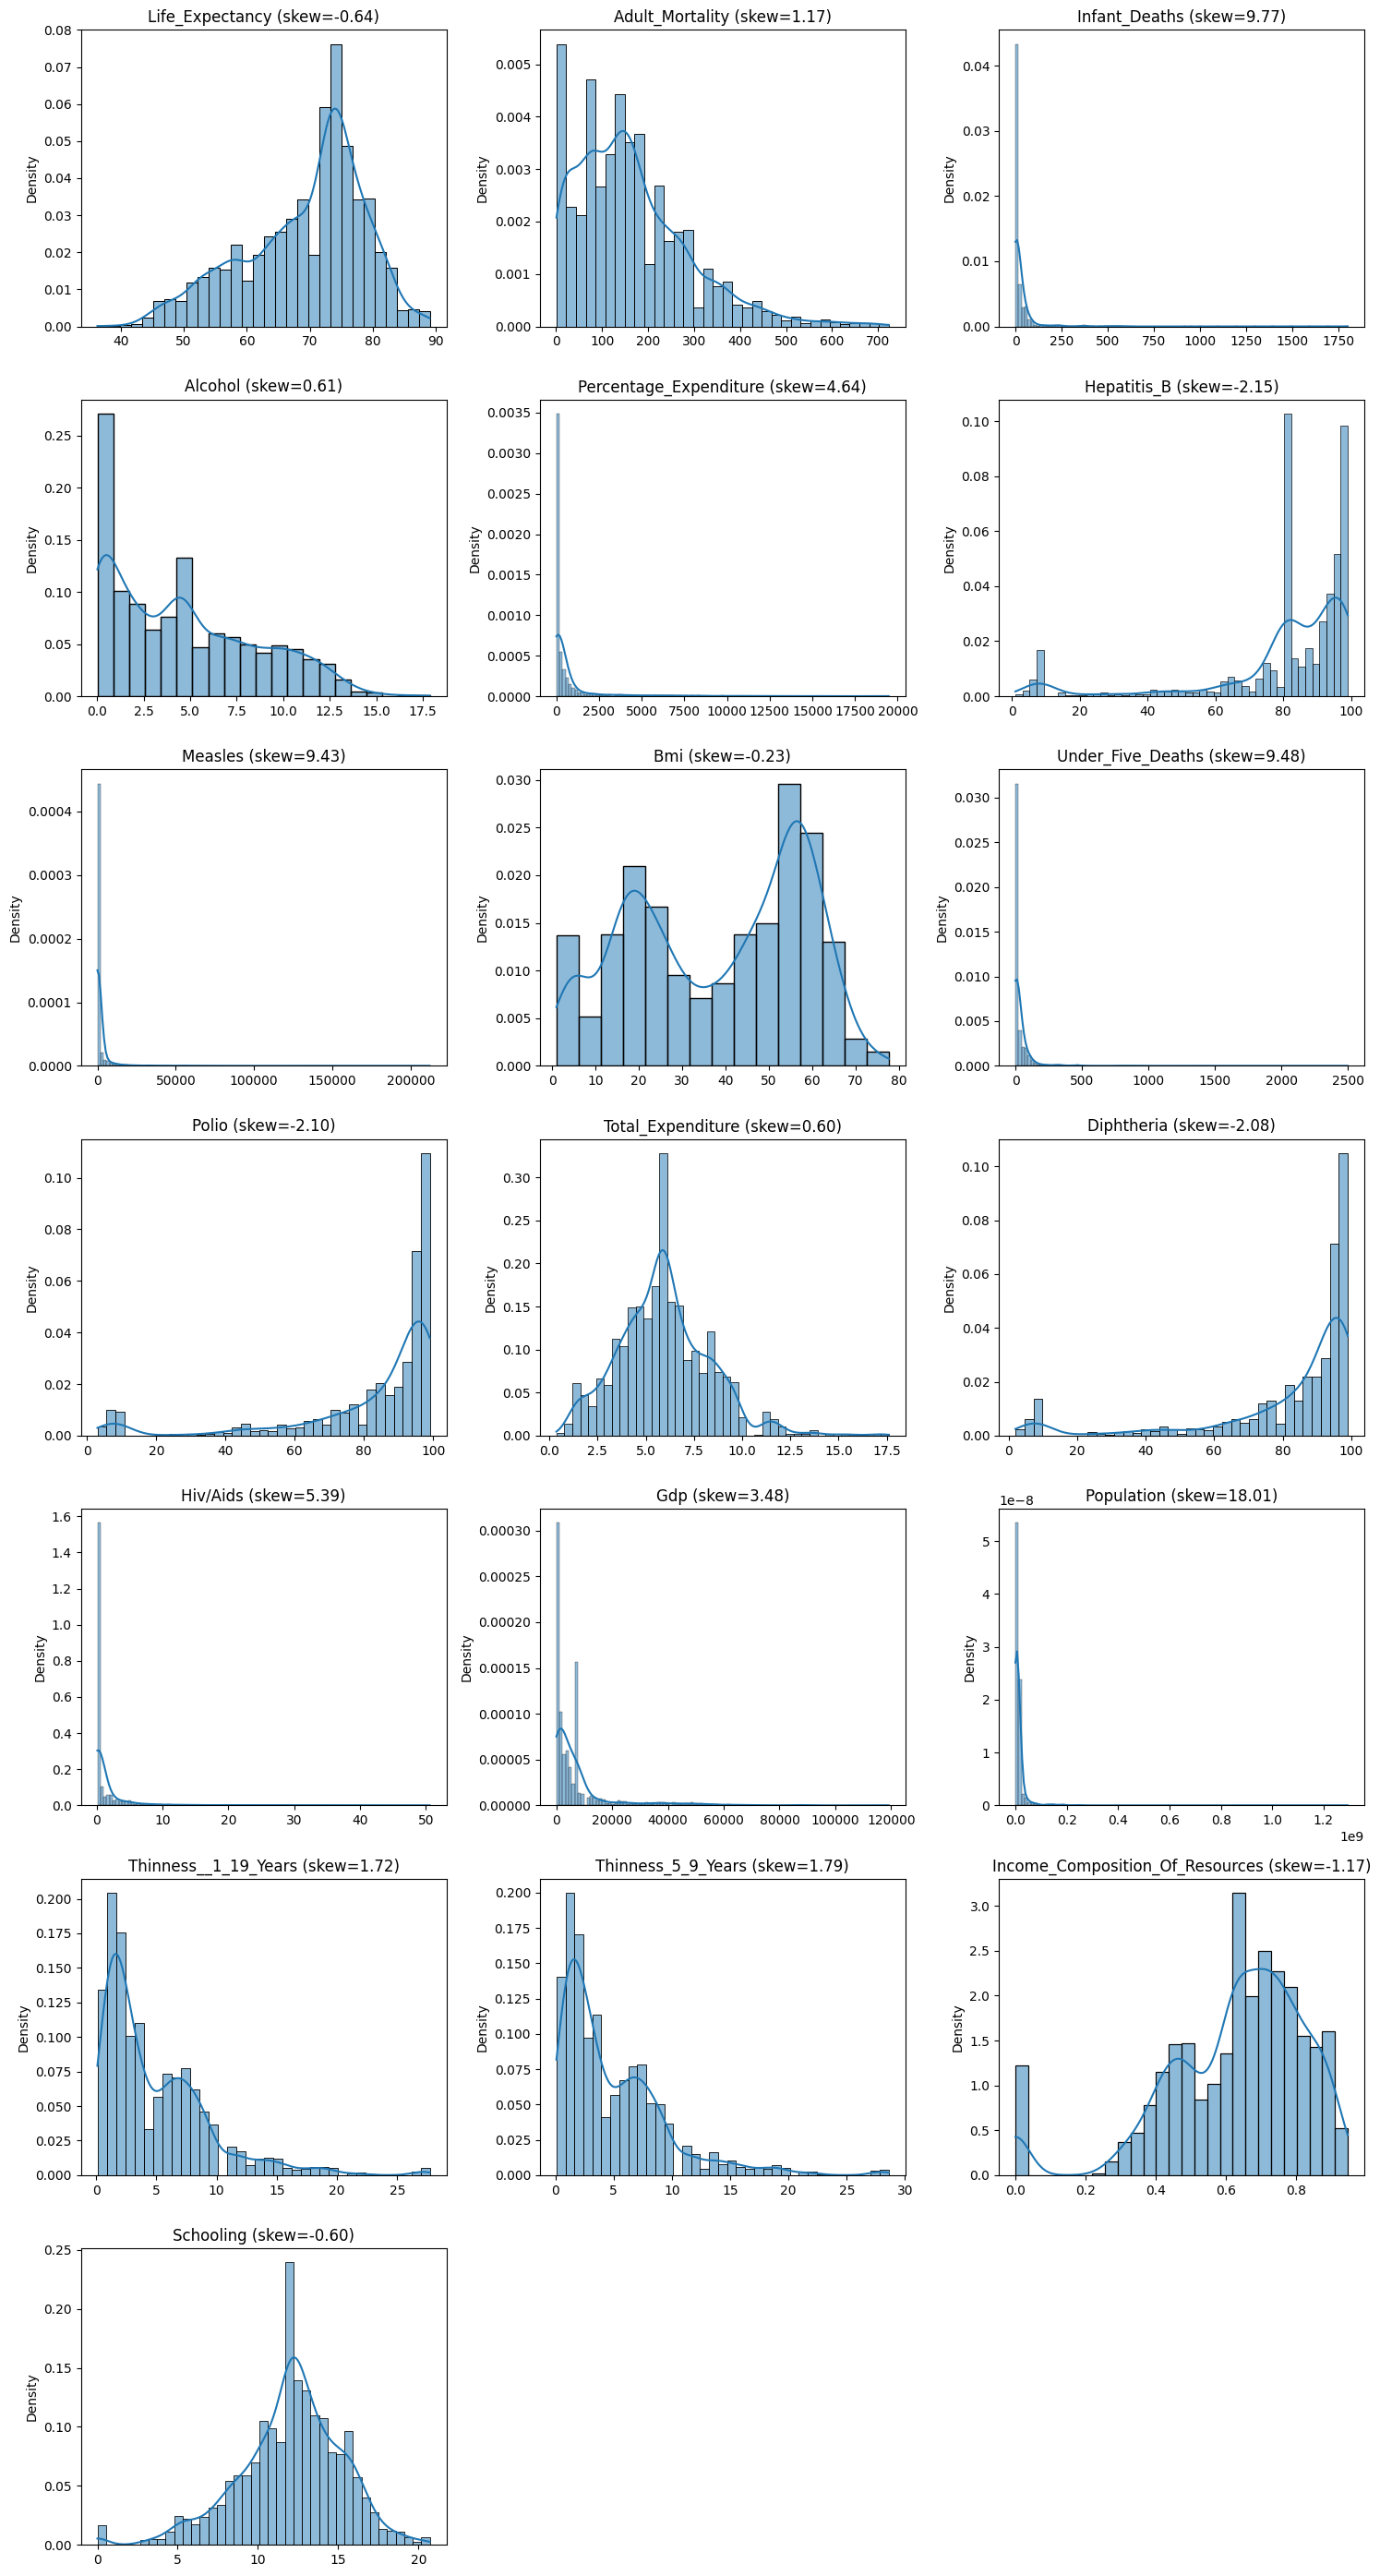

In [50]:
import seaborn as sns

cols = [c for c in df.select_dtypes(include=np.number).columns]
n = len(cols)
cols_per_row = 3
rows = (n + cols_per_row - 1) // cols_per_row

fig, axes = plt.subplots(rows, cols_per_row, figsize=(cols_per_row * 5, rows * 4))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i], stat='density', color='C0')
    axes[i].set_title(f'{col} (skew={df[col].skew():.2f})')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Density')

# remove any unused axes
for j in range(len(cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

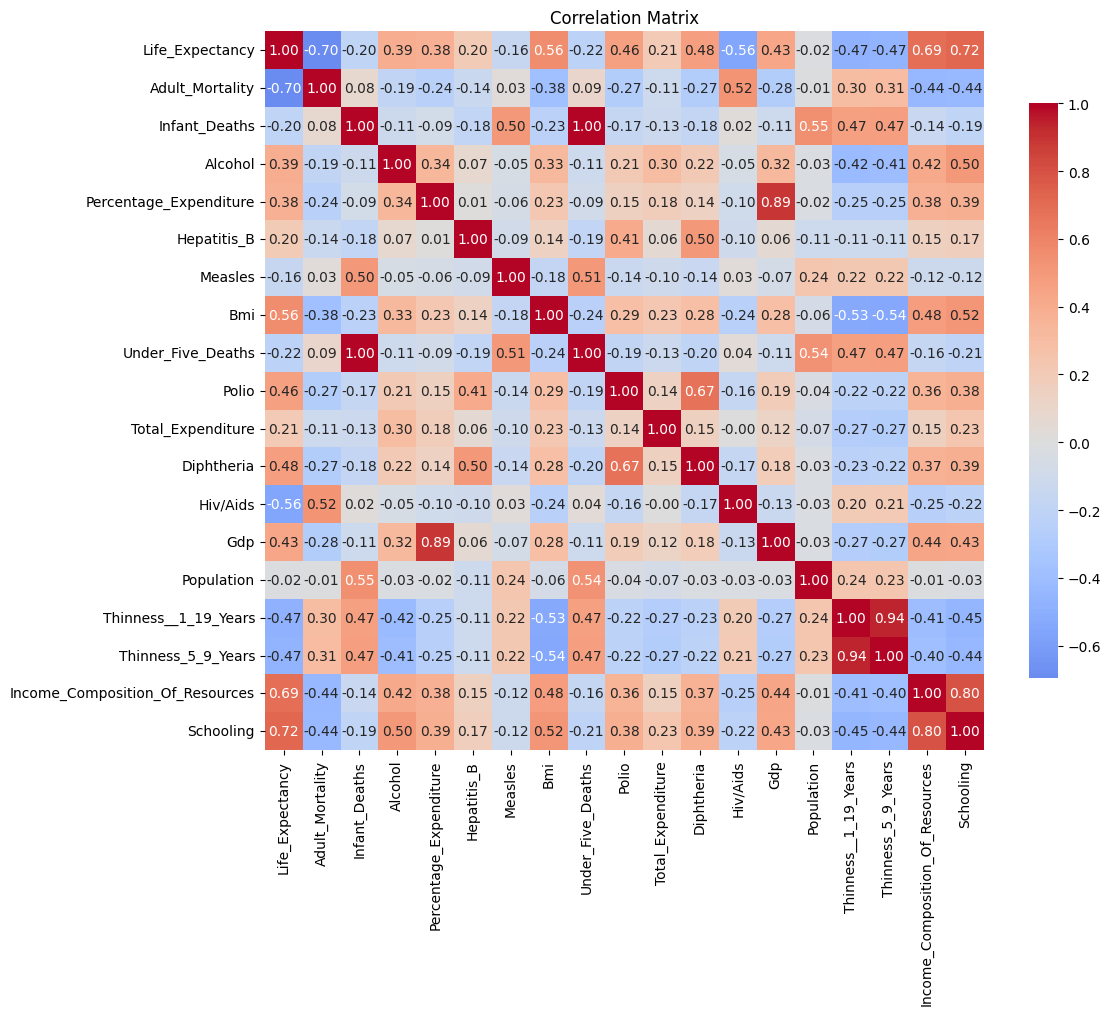

In [51]:
# Calculate and display correlation matrix
correlation_matrix = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [52]:
#removing population as there is hardly any corelation between population & life expectancy (-0.02)
df.drop(['Population'], axis=1, inplace=True)


In [53]:
categorical_cols = df.select_dtypes(include=['object']).columns
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))

# Generate mapping dictionary
status_mapping = {label: index for index, label in enumerate(le.classes_)}
print(status_mapping)

{'Developed': 0, 'Developing': 1}


In [54]:
training_r2_scores = []
testing_r2_scores = []
training_adj_r2_scores = []
testing_adj_r2_scores = []
training_rmse_scores = []
testing_rmse_scores = []

def ClearMetrics():
    training_r2_scores.clear()
    testing_r2_scores.clear()
    training_adj_r2_scores.clear()
    testing_adj_r2_scores.clear()
    training_rmse_scores.clear()
    testing_rmse_scores.clear()

def EvaluateModel(model, x_train, y_train, x_test, y_test):
    y_train_pred = model.predict(x_train)
    train_mse = mean_squared_error(y_train, y_train_pred)
    train_rmse = np.sqrt(train_mse)
    train_r2 = r2_score(y_train, y_train_pred)
    train_adj_r2 = 1 - (1 - train_r2) * (len(y_train) - 1) / (len(y_train) - x_train.shape[1] - 1)

    y_test_pred = model.predict(x_test)
    test_mse = mean_squared_error(y_test, y_test_pred)
    test_rmse = np.sqrt(test_mse)
    test_r2 = r2_score(y_test, y_test_pred)
    test_adj_r2 = 1 - (1 - test_r2) * (len(y_test) - 1) / (len(y_test) - x_test.shape[1] - 1)
    
    #print(f'Model: {model.__class__.__name__}')
    training_r2_scores.append(np.round(train_r2, 4))
    testing_r2_scores.append(np.round(test_r2, 4))
    training_adj_r2_scores.append(np.round(train_adj_r2, 4))
    testing_adj_r2_scores.append(np.round(test_adj_r2, 4))
    training_rmse_scores.append(np.round(train_rmse, 4))
    testing_rmse_scores.append(np.round(test_rmse, 4))
    #print("Training : R2 = {:.4f}, Adjusted R2 = {:.4f}, RMSE = {:.4f}".format(train_r2, train_adj_r2, train_rmse))
    #print("Testing  : R2 = {:.4f}, Adjusted R2 = {:.4f}, RMSE = {:.4f}".format(test_r2, test_adj_r2, test_rmse))

In [55]:
scaler = StandardScaler()
pt = PowerTransformer()

def EndToEndEvaluation(p_df, p_models, p_transform = False, p_scale = False):
    x = p_df.drop(columns=['Life_Expectancy'])
    y = p_df['Life_Expectancy']
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

    if p_transform == True:
        x_train = pt.fit_transform(x_train)
        x_test = pt.transform(x_test)

    if p_scale == True:
        x_train = scaler.fit_transform(x_train)
        x_test = scaler.transform(x_test)

    ClearMetrics()
    for model in p_models:
        model.fit(x_train, y_train)
        EvaluateModel(model, x_train, y_train, x_test, y_test)

    results_df = pd.DataFrame({
        'Model': [model.__class__.__name__ for model in p_models],
        'Train R2': training_r2_scores,
        'Test R2': testing_r2_scores,
        'Train Adjusted R2': training_adj_r2_scores,
        'Test Adjusted R2': testing_adj_r2_scores,
        'Train RMSE': training_rmse_scores,
        'Test RMSE': testing_rmse_scores
    })

    results_df = results_df.sort_values(by='Test R2', ascending=False).reset_index(drop=True)
    return results_df




In [56]:
models_without_tuning = [
    LinearRegression(),
    Ridge(),
    Lasso(),
    ElasticNet(),
    DecisionTreeRegressor(random_state=42),
    RandomForestRegressor(random_state=42),
    GradientBoostingRegressor(random_state=42),
    AdaBoostRegressor(random_state=42),
    SVR(),
    KNeighborsRegressor(),
    XGBRegressor(random_state=42),
    VotingRegressor(estimators=[
        ('lr', LinearRegression()),
        ('svr', SVR()),
        ('knn', KNeighborsRegressor()),
        ('rf', RandomForestRegressor(random_state=42))
    ])
]

df_without_eda = df.copy()
print("Results without EDA (without Hyperparameter Tuning):")
EndToEndEvaluation(df_without_eda, models_without_tuning)




Results without EDA (without Hyperparameter Tuning):


,Model,Train R2,Test R2,Train Adjusted R2,Test Adjusted R2,Train RMSE,Test RMSE
0,RandomForestRegressor,0.9946,0.9672,0.9945,0.9661,0.7061,1.6853
1,XGBRegressor,0.9991,0.9649,0.9990,0.9638,0.2948,1.7413
2,GradientBoostingRegressor,0.9606,0.9484,0.9603,0.9467,1.9009,2.1136
3,DecisionTreeRegressor,1.0000,0.9354,1.0000,0.9333,0.0000,2.3640
4,AdaBoostRegressor,0.9023,0.8939,0.9016,0.8906,2.9924,3.0292
5,VotingRegressor,0.8601,0.8217,0.8591,0.8161,3.5810,3.9269
6,Ridge,0.8199,0.8207,0.8185,0.8150,4.0639,3.9380
7,LinearRegression,0.8199,0.8207,0.8185,0.8150,4.0638,3.9377
8,ElasticNet,0.8112,0.8074,0.8098,0.8013,4.1601,4.0813
9,Lasso,0.8100,0.8071,0.8085,0.8010,4.1744,4.0844


### Performing EDA

In [57]:
df_eda = df.copy()

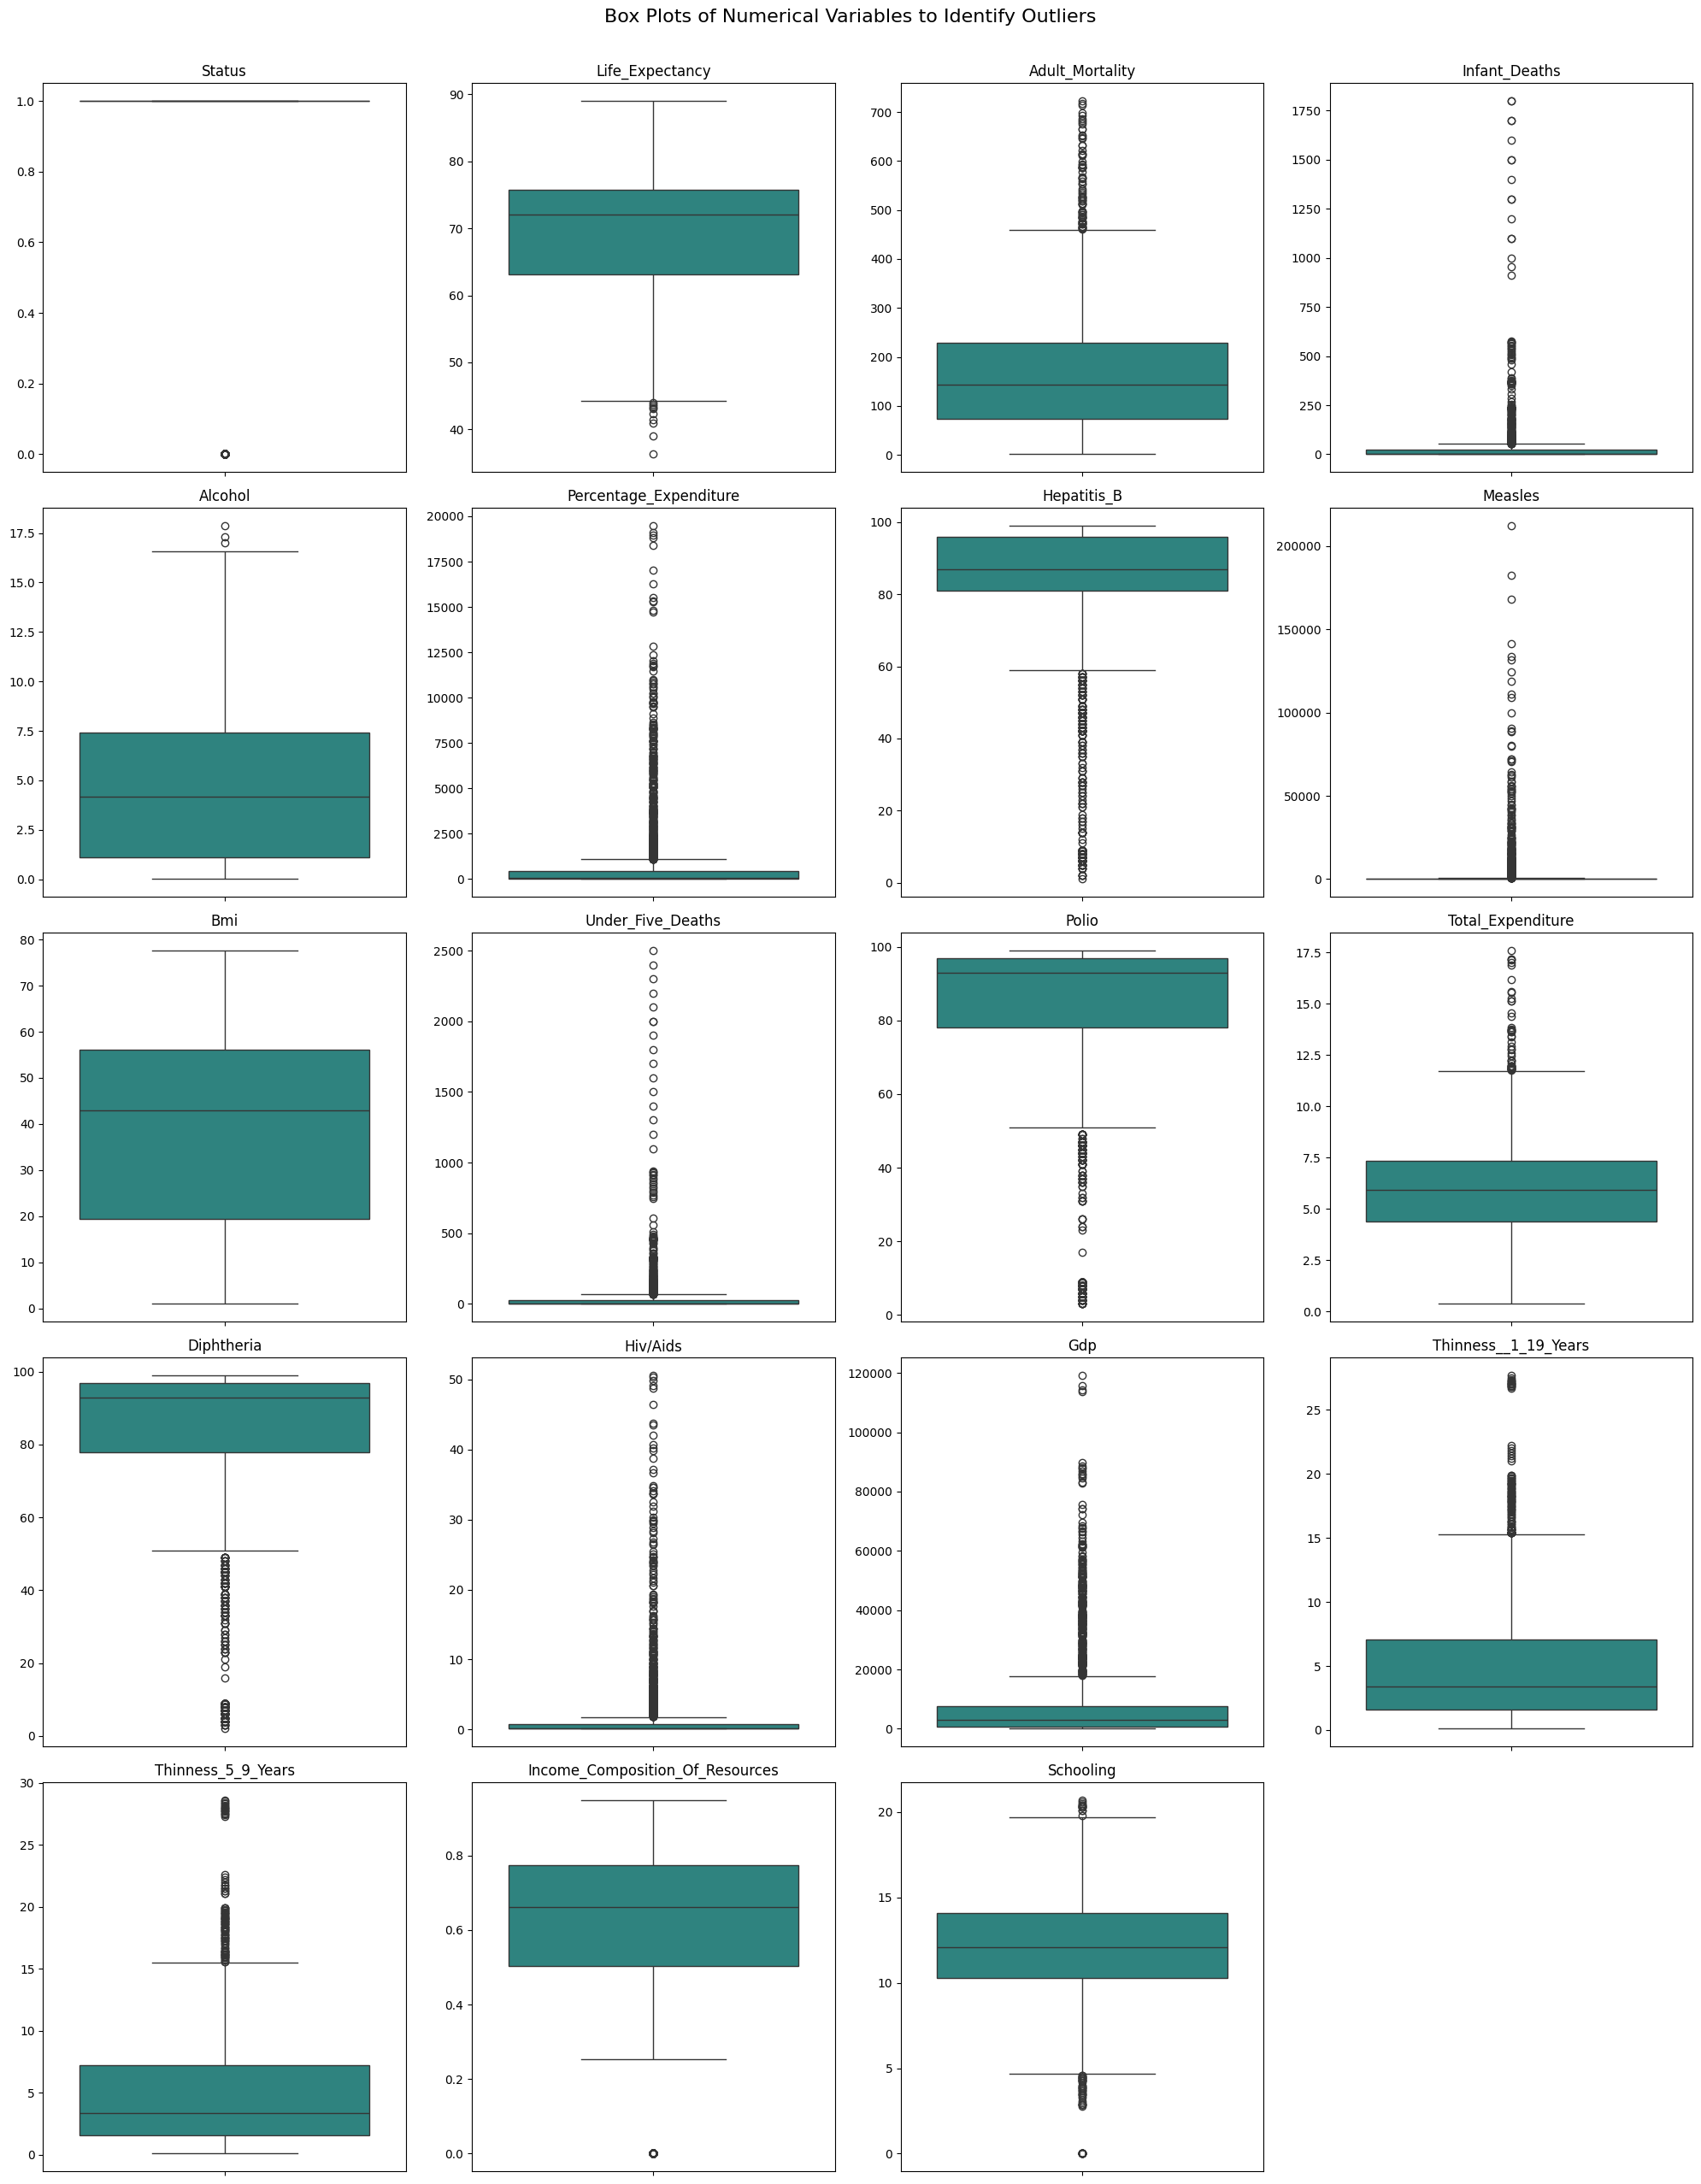

In [58]:
# outlier detection

numerical_cols = df_eda.select_dtypes(include=np.number).columns.tolist()

num_plots = len(numerical_cols)
num_rows = (num_plots + 3) // 4  # Adjust for 4 plots per row
num_cols = 4

fig, axes = plt.subplots(num_rows, num_cols, figsize=(20, 5 * num_rows))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(y=df_eda[col], ax=axes[i], palette='viridis')
    axes[i].set_title(col, fontsize=12)
    axes[i].set_ylabel('') # Remove y-label for cleaner look
    axes[i].tick_params(axis='y', labelsize=10)

# Hide any unused subplots
for i in range(num_plots, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.suptitle('Box Plots of Numerical Variables to Identify Outliers', y=1.02, fontsize=16)
plt.show()

In [59]:
def cap_outliers_iqr(p_df, p_column):
    Q1 = p_df[p_column].quantile(0.25)
    Q3 = p_df[p_column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Cap values outside the bounds
    p_df[p_column] = np.where(p_df[p_column] < lower_bound, lower_bound, p_df[p_column])
    p_df[p_column] = np.where(p_df[p_column] > upper_bound, upper_bound, p_df[p_column])

#Handling outliers by capping them using IQR method
for col in df_eda.columns:
    if col not in ['Status']:
        cap_outliers_iqr(df_eda, col)

In [60]:
df_eda.describe().T

,count,mean,std,min,25%,50%,75%,max
Status,2928.0,0.825137,0.379915,0.000000,1.000000,1.000000,1.000000,1.000000
Life_Expectancy,2928.0,69.233197,9.500077,44.200000,63.100000,72.100000,75.700000,89.000000
Adult_Mortality,2928.0,162.087432,115.866689,1.000000,74.000000,144.000000,228.000000,459.000000
Infant_Deaths,2928.0,13.681694,19.124887,0.000000,0.000000,3.000000,22.000000,55.000000
Alcohol,2928.0,4.614291,3.913102,0.010000,1.107500,4.160000,7.400000,16.838750
Percentage_Expenditure,2928.0,284.889600,390.385763,0.000000,4.853964,65.611455,442.614322,1099.254858
Hepatitis_B,2928.0,84.642625,12.776946,58.402105,80.960842,87.000000,96.000000,99.000000
Measles,2928.0,235.469518,355.694920,0.000000,0.000000,17.000000,362.250000,905.625000
Bmi,2928.0,38.235394,19.850184,1.000000,19.400000,43.000000,56.100000,77.600000
Under_Five_Deaths,2928.0,18.027322,25.215584,0.000000,0.000000,4.000000,28.000000,70.000000


In [61]:
df_eda.select_dtypes(include=np.number).skew()

Status                            -1.712798
Life_Expectancy                   -0.624228
Adult_Mortality                    0.777243
Infant_Deaths                      1.284006
Alcohol                            0.604394
Percentage_Expenditure             1.243088
Hepatitis_B                       -0.817629
Measles                            1.181978
Bmi                               -0.231828
Under_Five_Deaths                  1.234535
Polio                             -1.228135
Total_Expenditure                  0.264491
Diphtheria                        -1.247082
Hiv/Aids                           1.204141
Gdp                                1.182119
Thinness__1_19_Years               1.076662
Thinness_5_9_Years                 1.093203
Income_Composition_Of_Resources   -0.868610
Schooling                         -0.300539
dtype: float64

In [62]:
print("Results with EDA and scaling (without tuning):")
EndToEndEvaluation(df_eda, models_without_tuning, True, True)

Results with EDA and scaling (without tuning):


,Model,Train R2,Test R2,Train Adjusted R2,Test Adjusted R2,Train RMSE,Test RMSE
0,RandomForestRegressor,0.9945,0.9673,0.9945,0.9663,0.7083,1.6797
1,XGBRegressor,0.9993,0.9621,0.9993,0.9609,0.2604,1.8073
2,GradientBoostingRegressor,0.9567,0.9464,0.9563,0.9447,1.9879,2.1507
3,VotingRegressor,0.9437,0.9326,0.9432,0.9304,2.2660,2.4125
4,DecisionTreeRegressor,1.0000,0.9286,1.0000,0.9263,0.0000,2.4827
5,KNeighborsRegressor,0.9382,0.9140,0.9377,0.9113,2.3733,2.7239
6,SVR,0.8902,0.8998,0.8893,0.8967,3.1645,2.9399
7,AdaBoostRegressor,0.9046,0.8955,0.9039,0.8922,2.9489,3.0025
8,Ridge,0.8243,0.8218,0.8229,0.8162,4.0025,3.9213
9,LinearRegression,0.8243,0.8218,0.8229,0.8161,4.0024,3.9218


#### Observation : RandomForestRegressor is the best performing model with and without EDA. RandomForestRegressor is performing slightly better with EDA & scaling. 

#####            Train R2	Test R2	Train Adjusted R2	Test Adjusted R2	Train RMSE	Test RMSE
##### WithOut EDA =>  0.9946 , 0.9672 , 0.9945 , 0.9661 , 0.7061 , 1.6853
##### With EDA =>     0.9945 , 0.9673 , 0.9945 , 0.9663 , 0.7083 , 1.6797

In [66]:
print("Results with EDA and scaling (without hyperparameter tuning):")
EndToEndEvaluation(df_eda, models_without_tuning, False, True)

Results with EDA and scaling (without hyperparameter tuning):


,Model,Train R2,Test R2,Train Adjusted R2,Test Adjusted R2,Train RMSE,Test RMSE
0,RandomForestRegressor,0.9945,0.9676,0.9944,0.9665,0.7087,1.6727
1,XGBRegressor,0.9993,0.9621,0.9993,0.9609,0.2604,1.8073
2,GradientBoostingRegressor,0.9567,0.9465,0.9563,0.9448,1.9879,2.1494
3,VotingRegressor,0.9481,0.9348,0.9477,0.9328,2.1743,2.3712
4,DecisionTreeRegressor,1.0000,0.9272,1.0000,0.9248,0.0000,2.5073
5,KNeighborsRegressor,0.9439,0.9115,0.9434,0.9087,2.2626,2.7638
6,SVR,0.8945,0.8987,0.8937,0.8955,3.1010,2.9560
7,AdaBoostRegressor,0.8996,0.8884,0.8988,0.8849,3.0256,3.1032
8,Ridge,0.8530,0.8549,0.8519,0.8502,3.6607,3.5391
9,LinearRegression,0.8531,0.8549,0.8519,0.8502,3.6603,3.5391


#### Observation : RandomForestRegressor is performing best with with EDA & scaling & without transformation. So selecting RandomForestRegressor with EDA & scaling. Now we are going to try hyperparameter tuning on RF algo to get best model

In [67]:
random_forest_model = models_without_tuning[5]

Param_grid_rf = {
    'n_estimators': [100, 150, 200, 250, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

x = df_eda.drop(columns=['Life_Expectancy'])
y = df_eda['Life_Expectancy']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)
grid_search = GridSearchCV(estimator=random_forest_model, param_grid=Param_grid_rf, cv=5, n_jobs=-1, verbose=2)
grid_search.fit(x_train, y_train)

best_rf_model = grid_search.best_estimator_
print("Best Hyperparameters for Random Forest:", grid_search.best_params_)


Fitting 5 folds for each of 180 candidates, totalling 900 fits
Best Hyperparameters for Random Forest: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 250}


In [68]:
l_models = [best_rf_model]
print("Results with EDA, Scaling and Hyperparameter Tuning:")
EndToEndEvaluation(df_eda, l_models, False, True)

Results with EDA, Scaling and Hyperparameter Tuning:


,Model,Train R2,Test R2,Train Adjusted R2,Test Adjusted R2,Train RMSE,Test RMSE
0,RandomForestRegressor,0.9947,0.9675,0.9947,0.9664,0.6955,1.6755


In [69]:
l_models.clear()
l_models.append(random_forest_model)
print("Results with EDA & scaling (without Hyperparameter Tuning):")
EndToEndEvaluation(df_eda, l_models, False, True)

Results with EDA & scaling (without Hyperparameter Tuning):


,Model,Train R2,Test R2,Train Adjusted R2,Test Adjusted R2,Train RMSE,Test RMSE
0,RandomForestRegressor,0.9945,0.9676,0.9944,0.9665,0.7087,1.6727


#### Best performing model : RandomForestRegressor without hyperparamer tuning

In [70]:
#dump the best performing model
joblib.dump(random_forest_model, 'RandomForestRegressor_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
#joblib.dump(pt, 'powerTransformer.pkl')

['scaler.pkl']

In [71]:
df_eda.columns

Index(['Status', 'Life_Expectancy', 'Adult_Mortality', 'Infant_Deaths',
       'Alcohol', 'Percentage_Expenditure', 'Hepatitis_B', 'Measles', 'Bmi',
       'Under_Five_Deaths', 'Polio', 'Total_Expenditure', 'Diphtheria',
       'Hiv/Aids', 'Gdp', 'Thinness__1_19_Years', 'Thinness_5_9_Years',
       'Income_Composition_Of_Resources', 'Schooling'],
      dtype='str')